# Wash Trading · Part 1 · v1 Mechanism Results

**Mechanism: active co-arrival + one directed edge per event.**
A shared controller schedules the paired wallets into the SAME timestep and posts a crossing
order pair inside the current bid-ask spread, so they match EACH OTHER in that timestep's single
batch clear. The 3 wallets form a directed cycle A->B->C->A; after one full cycle (n events)
the group's net position is back to zero.

This notebook validates and shows the **mechanism** (not scientific conclusions):
1. two control conditions run and behave as expected;
2. the wash group's net position returns to 0 at every cycle boundary;
3. per-wallet position trajectories (rotating triangle);
4. wash-volume share;
5. why `wash_eps` is NOT a spillover knob, and multi-seed robustness.

> Data sources: `matched_orders` (trade log; positions rebuilt from it) + `controller.event_log`
> (ground-truth label stream). Nothing in `marketsim/` is modified.

In [1]:
import os, sys

def _find_root(start):
    d = os.path.abspath(start)
    while True:
        if os.path.isdir(os.path.join(d, "marketsim")) and os.path.isdir(os.path.join(d, "capstone codes")):
            return d
        p = os.path.dirname(d)
        if p == d:
            return None
        d = p

ROOT = _find_root(os.getcwd())
assert ROOT, "repo root not found (need marketsim/ + 'capstone codes/')"
for p in (ROOT, os.path.join(ROOT, "capstone codes")):
    if p not in sys.path:
        sys.path.insert(0, p)

import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from washtrade.v1 import WashTradingSimulator
from washtrade.v1 import analysis as A

def seed_all(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)

def run(composition, seed=0, lam_wash=None, wash_eps=0.0, sim_time=2000):
    seed_all(seed)
    sim = WashTradingSimulator(composition, sim_time=sim_time, lam=5e-3,
                               lam_wash=lam_wash, wash_eps=wash_eps, wash_seed=seed)
    sim.run()
    return sim

print("ready · repo root:", os.path.basename(ROOT))

ready · repo root: wash-trading-capstone


## A. Two control conditions

- **Negative control (all-ZI):** no wash wallets, the controller stays idle (0 events) -- used to
  measure the false-positive baseline.
- **Treatment (ZI + 3 WashTrader):** `lam_wash=0.05` (a wash event every ~20 steps on average,
  T=2000 -> ~100 events).

In [2]:
ctrl = run({"ZI": 14}, seed=0)
trt  = run({"ZI": 13, "WashTrader": 3}, seed=0, lam_wash=0.05)

summary = pd.DataFrame({"all-ZI control": A.summarize(ctrl),
                        "ZI+3 WashTrader": A.summarize(trt)}).T
summary

,n_wallets,n_events,n_self_trades,self_trade_rate,total_trade_legs,wash_trade_legs,wash_leg_share,wash_group_final_net
all-ZI control,0.0,0.0,0.0,NaN,30.0,0.0,0.00000,0.0
ZI+3 WashTrader,3.0,89.0,89.0,1.0,198.0,178.0,0.89899,0.0


## B. Net-zero rotation

With `wash_eps=0` both legs sit at the spread midpoint and are essentially never intercepted;
every completed cycle of 3 events returns the wash group's net position to 0. Below: the group
net position over time, and the range of the net at each cycle boundary (target: always 0).

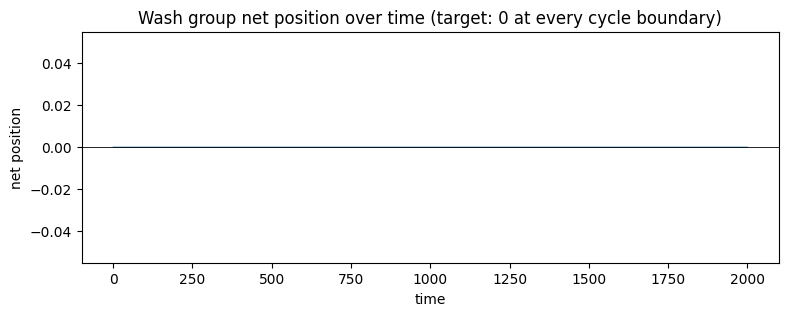

completed cycles: 29 | cycle-boundary net range: [0, 0] (target all 0)


In [3]:
g = A.wash_group_series(trt)
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(g.index, g.values, lw=0.8)
ax.axhline(0, color="k", lw=0.6)
ax.set_title("Wash group net position over time (target: 0 at every cycle boundary)")
ax.set_xlabel("time"); ax.set_ylabel("net position")
plt.show()

nets = A.cycle_boundary_nets(trt)
print(f"completed cycles: {len(nets)} | cycle-boundary net range: [{min(nets)}, {max(nets)}] (target all 0)")

## C. Per-wallet position trajectories (rotating triangle)

Each wallet oscillates within +/- q; the three phase-shifted wallets rotate so their sum hugs 0.

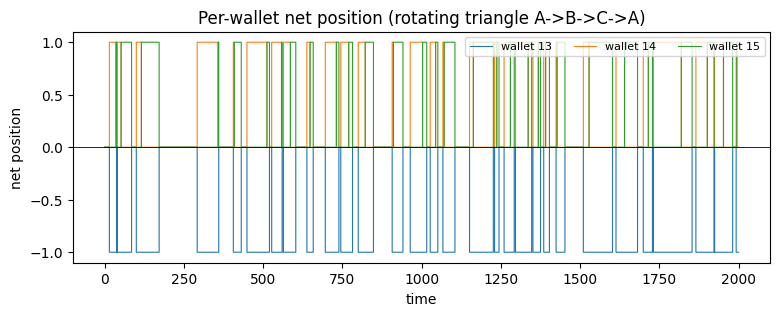

In [4]:
ts = A.position_timeseries(trt)
fig, ax = plt.subplots(figsize=(9, 3))
for aid in ts.columns:
    ax.step(ts.index, ts[aid], lw=0.8, where="post", label=f"wallet {aid}")
ax.axhline(0, color="k", lw=0.6)
ax.legend(loc="upper right", ncol=3, fontsize=8)
ax.set_title("Per-wallet net position (rotating triangle A->B->C->A)")
ax.set_xlabel("time"); ax.set_ylabel("net position")
plt.show()

## D. Wash-volume share

`total_trade_legs` is the number of matched-order entries (2 per trade); `wash_trade_legs` is the
number of legs a wash wallet participated in. `self_trade_rate` is the fraction of events whose two
legs matched each other within the same event.

In [5]:
s = A.summarize(trt)
print(f"total trade legs         : {s['total_trade_legs']}")
print(f"wash-attributable legs   : {s['wash_trade_legs']}  ({s['wash_leg_share']*100:.1f}% of all legs)")
print(f"wash events fired        : {s['n_events']}")
print(f"self-trade success       : {s['n_self_trades']}/{s['n_events']} = {s['self_trade_rate']*100:.1f}%")
print(f"wash group final net     : {s['wash_group_final_net']}")

total trade legs         : 198
wash-attributable legs   : 178  (89.9% of all legs)
wash events fired        : 89
self-trade success       : 89/89 = 100.0%
wash group final net     : 0
